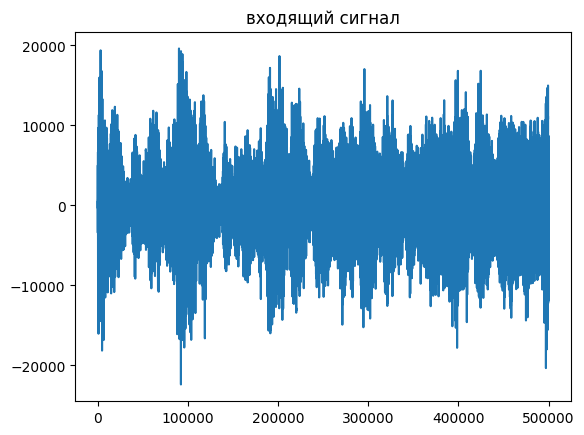

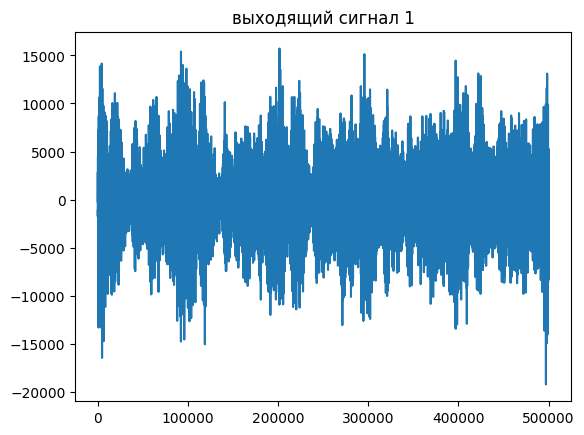

In [ ]:
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
from math import pi, cos, sin

def recursive_fft(x):
    n = len(x)
    if n == 1:
        return x
    even = recursive_fft(x[::2])
    odd = recursive_fft(x[1::2])
    w = [np.exp(-2j*pi*k/n)*odd[k] for k in range(n//2)]
    return [even[k] + w[k] for k in range(n//2)] + [even[k] - w[k] for k in range(n//2)]

def my_fft1(signal):
    n = len(signal)
    size = 2**int(np.ceil(np.log2(n)))
    padded = np.zeros(size, dtype=complex)
    padded[:n] = signal
    return np.array(recursive_fft(padded))

def ifft1(fft_signal):
    fft_signal = np.asarray(fft_signal, dtype=complex)
    return np.conj(np.array(recursive_fft(np.conj(fft_signal))))/len(fft_signal)

def fftshift1(fft_signal):
    n = len(fft_signal)
    return np.roll(fft_signal, n//2)

def ifftshift1(fft_signal):
    n = len(fft_signal)
    return np.roll(fft_signal, -n//2)

sample_rate, data_orig = wavfile.read('-imperskiy-marsh_d_d_d-star-wars.wav')
data=data_orig[200000:700000, 0]
n=len(data)

wavfile.write('unfiltered_audio.wav', sample_rate, data.astype(np.int16))
plt.plot(data)
plt.title('входящий сигнал')
plt.show()

#1
fft_data = my_fft1(data.astype(complex))
fshift = fftshift1(fft_data)

mask_percent=0.05
c = len(fshift)//2
mask = np.zeros_like(fshift)
r = int(len(fshift)*mask_percent/2)
mask[c-r : c+r] = 1

filtered = fshift*mask

reconstructed = np.real(ifft1(ifftshift1(filtered)))
reconstructed = reconstructed[:n]

wavfile.write('filtered_audio1.wav', sample_rate, reconstructed.astype(np.int16))
plt.plot(reconstructed)
plt.title('выходящий сигнал 1')
plt.show()